In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import GPT2Tokenizer
import math
import copy

# ==========================================
# 1. Diffusion Utilities (Sqrt Schedule)
# ==========================================
def compute_sqrt_alpha_bar(t, T_max=2000, s=1e-4):
    """
    Sqrt noise schedule from Diffusion-LM (Appendix A).
    alpha_bar_t = 1 - sqrt(t/T + s)
    """
    # t is expected to be a tensor of shape (batch_size, 1, 1)
    t_norm = t.float() / T_max
    alpha_bar = 1.0 - torch.sqrt(t_norm + s)
    # Clamp to prevent negative variances or exact zeros
    return torch.clamp(alpha_bar, min=1e-5, max=0.9999)

class EMA:
    """Exponential Moving Average for model weights (Crucial for TRM stability)"""
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                new_average = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_average.clone()

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]

In [7]:
# ==========================================
# 2. Model Architecture (TRM + Diffusion)
# ==========================================
class BidirectionalTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.norm1 = nn.LayerNorm(d_model)
        
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        q = self.q_proj(x).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        attn_out = F.scaled_dot_product_attention(q, k, v, is_causal=False)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        
        x = self.norm1(x + self.out_proj(attn_out))
        x = self.norm2(x + self.mlp(x))
        return x

class TRM_Diffusion(nn.Module):
    def __init__(self, vocab_size, d_model=512, n_heads=8, d_ff=2048, num_layers=4):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        # End-to-End Embeddings
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.token_emb.weight.requires_grad = True
        self.pos_emb = nn.Embedding(1024, d_model) 
        
        # Timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )
        
        # TRM Backbone
        self.layers = nn.ModuleList([
            BidirectionalTransformerLayer(d_model, n_heads, d_ff) 
            for _ in range(num_layers)
        ])
        
        self.output_head = nn.Linear(d_model, d_model)
        self.z_init = nn.Parameter(torch.randn(1, 1, d_model))
        self.lm_head = nn.Linear(d_model, vocab_size)

    def get_sinusoidal_embeddings(self, t):
        half_dim = self.d_model // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

    def latent_recursion(self, x_t_emb, z, t_emb, n, pos_embeddings):
        for _ in range(n):
            combined_state = x_t_emb + z + t_emb.unsqueeze(1) + pos_embeddings
            for layer in self.layers:
                combined_state = layer(combined_state)
            z = combined_state
            
        pred_x0_emb = self.output_head(z)
        return pred_x0_emb, z

    def deep_recursion(self, x_t_emb, z, t_emb, n, T, pos_embeddings):
        for _ in range(T):
            pred_x0_emb, z = self.latent_recursion(x_t_emb, z, t_emb, n, pos_embeddings)
        return pred_x0_emb, z

    def forward(self, x_t_emb, t, positions, n=6, T=3): 
        # FIX 1: Convert integer timesteps to continuous sinusoidal
        sinusoidal_t = self.get_sinusoidal_embeddings(t)
        t_emb = self.time_mlp(sinusoidal_t)
        
        pos_embeddings = self.pos_emb(positions)
        
        # FIX 2: Dynamically expand z_init using x_t_emb's shape
        bs, seq_len, _ = x_t_emb.shape
        z = self.z_init.expand(bs, seq_len, -1)
        
        pred_x0_emb, z_final = self.deep_recursion(x_t_emb, z, t_emb, n, T, pos_embeddings)
        
        # FIX 3: Return ONLY pred_x0_emb so we don't crash the tuple unpacker
        return pred_x0_emb

In [8]:
import torch
import torch.nn.functional as F
from transformers import GPT2Tokenizer
import math

# 1. Include your TRM_Diffusion class and BidirectionalTransformerLayer here
# (Copy them from your training script so the model can be instantiated)
# class BidirectionalTransformerLayer(nn.Module): ...
# class TRM_Diffusion(nn.Module): ...

def compute_sqrt_alpha_bar(t, T_max=2000, s=1e-4):
    """Sqrt noise schedule (matches the training script)"""
    t_norm = t.float() / T_max
    alpha_bar = 1.0 - torch.sqrt(t_norm + s)
    return torch.clamp(alpha_bar, min=1e-5, max=0.9999)

def clamp_to_nearest_word(pred_x0_emb, vocab_embeddings):
    """
    THE CLAMPING TRICK:
    Finds the closest actual word embedding for each predicted continuous vector.
    Using L2 distance: ||pred - vocab||^2
    """
    # pred_x0_emb shape: (batch_size, seq_len, d_model)
    # vocab_embeddings shape: (vocab_size, d_model)
    
    # Calculate Euclidean distance between predictions and all vocab words
    dists = torch.cdist(pred_x0_emb, vocab_embeddings, p=2) # shape: (batch, seq, vocab)
    
    # Find the index of the closest word for each position
    nearest_idx = dists.argmin(dim=-1) 
    
    # Snap the vector to exactly that word's embedding
    clamped_x0_emb = vocab_embeddings[nearest_idx]
    
    return clamped_x0_emb, nearest_idx

In [4]:
@torch.no_grad()
def generate_with_prompt(model_path, prompt_text, seq_len=256, temperature=0.7):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    T_DIFFUSION = 2000
    CLAMP_START = 500 
    
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    vocab_size = len(tokenizer)
    
    model = TRM_Diffusion(vocab_size=vocab_size, d_model=512, num_layers=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])
    model.eval()
    
    vocab_embeddings = model.token_emb.weight 
    positions = torch.arange(seq_len, device=device).unsqueeze(0)
    pos_embeddings = model.pos_emb(positions)
    
    # ==========================================
    # 1. PREPARE THE PROMPT
    # ==========================================
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")["input_ids"].to(device)
    prompt_len = prompt_tokens.shape[1]
    
    # Get the clean, exact embeddings for the prompt (Word + Position)
    clean_prompt_emb = model.token_emb(prompt_tokens) + pos_embeddings[:, :prompt_len, :]
    
    print(f"Prompt length: {prompt_len} tokens. Generating remaining {seq_len - prompt_len} tokens...")
    
    # Start with pure Gaussian Noise for the whole sequence
    x_t_emb = torch.randn(1, seq_len, model.d_model, device=device)
    
    for t_step in reversed(range(1, T_DIFFUSION + 1)):
        t_tensor = torch.full((1,), t_step, device=device, dtype=torch.long)
        
        # ==========================================
        # 2. FORCE THE PROMPT INTO THE NOISE
        # ==========================================
        # We calculate exactly how much noise the prompt *should* have at this timestep
        alpha_bar_t = compute_sqrt_alpha_bar(t_tensor).view(-1, 1, 1)
        prompt_noise = torch.randn_like(clean_prompt_emb)
        
        # Create the mathematically accurate noised prompt
        noised_prompt = torch.sqrt(alpha_bar_t) * clean_prompt_emb + torch.sqrt(1 - alpha_bar_t) * prompt_noise
        
        # Overwrite the beginning of the sequence with our noised prompt!
        x_t_emb[:, :prompt_len, :] = noised_prompt
        
        # ==========================================
        # 3. STANDARD TRM DENOISING (Predicts the whole sequence)
        # ==========================================
        z = model.z_init.expand(1, seq_len, -1)
        pred_x0_combined, _, _ = model.deep_recursion(x_t_emb, z, t_tensor, n=6, T=3)
        
        # --- DELAYED CLAMPING ---
        if t_step <= CLAMP_START:
            pred_word_emb = pred_x0_combined - pos_embeddings
            clamped_word_emb, token_ids = clamp_to_nearest_word(pred_word_emb, vocab_embeddings)
            final_x0 = clamped_word_emb + pos_embeddings
            
            # FORCE the prompt tokens to be exactly correct during clamping
            final_x0[:, :prompt_len, :] = clean_prompt_emb
        else:
            final_x0 = pred_x0_combined 
            final_x0[:, :prompt_len, :] = clean_prompt_emb # Keep prompt anchored
            
        # --- DDPM POSTERIOR MATH (Same as before) ---
        if t_step > 1:
            t_minus_1 = torch.full((1,), t_step - 1, device=device, dtype=torch.long)
            alpha_bar_t_minus_1 = compute_sqrt_alpha_bar(t_minus_1).view(-1, 1, 1)
            alpha_t = alpha_bar_t / alpha_bar_t_minus_1
            beta_t = 1.0 - alpha_t
            
            c1 = (torch.sqrt(alpha_bar_t_minus_1) * beta_t) / (1.0 - alpha_bar_t)
            c2 = (torch.sqrt(alpha_t) * (1.0 - alpha_bar_t_minus_1)) / (1.0 - alpha_bar_t)
            
            posterior_mean = c1 * final_x0 + c2 * x_t_emb
            posterior_variance = ((1.0 - alpha_bar_t_minus_1) / (1.0 - alpha_bar_t)) * beta_t
            
            noise = torch.randn_like(x_t_emb) * temperature
            x_t_emb = posterior_mean + torch.sqrt(posterior_variance) * noise
        else:
            x_t_emb = final_x0

    # Decode the final token IDs
    final_text = tokenizer.batch_decode(token_ids, skip_special_tokens=True)
    print("\n--- Generated Story ---")
    print(final_text[0])
    return final_text

# Example Usage:
# generate_with_prompt("trm_diffusion_step_40000.pt", "Once upon a time, there was a little dog named")

In [6]:

generate_with_prompt("trm_diffusion_step_20000.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named,. outside was picked all a and, for hard
 the years and a
 took on by andMom day the there.. if was new andmymy water
 with he feel to so and but find said he come what him. the was
 the


['Once upon a time, there was a little dog named,. outside was picked all a and, for hard\n the years and a\n took on by andMom day the there.. if was new andmymy water\n with he feel to so and but find said he come what him. the was\n the']

In [7]:

generate_with_prompt("trm_diffusion_step_30000.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named and can with and. One to thought at, to
 on there her sad. in, But day The very dog like a., get Tom to play, to find, a and and.,
 stopped big was was lived heard a together and
!"


['Once upon a time, there was a little dog named and can with and. One to thought at, to\n on there her sad. in, But day The very dog like a., get Tom to play, to find, a and and.,\n stopped big was was lived heard a together and\n!"']

In [8]:

generate_with_prompt("trm_diffusion_step_40000.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time there there was a, dog and and and and and, dad,my and and,, and,,,,,,, and and and,,, and and,, and, and, and,,,my, and and, and,,,, Tim, and and and


['Once upon a time there there was a, dog and and and and and, dad,my and and,, and,,,,,,, and and and,,, and and,, and, and, and,,,my, and and, and,,,, Tim, and and and']

In [11]:
generate_with_prompt("trm_diffusion_step_50000.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time there there park named named dog named named park park with One One One One One One One One One One One One very One One, sad with, One showed One park, very with he One sad would on verySuddenly sad sad sad,,, sad, sad sad had sad did on, on


['Once upon a time there there park named named dog named named park park with One One One One One One One One One One One One very One One, sad with, One showed One park, very with he One sad would on verySuddenly sad sad sad,,, sad, sad sad had sad did on, on']

In [13]:
generate_with_prompt("trm_diffusion_epoch_1_complete.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon didn time park animals opened park little park named liked didn toys One park years toys One One years named toys years toys loved park His liked liked One park named didn One named toys


['Once upon didn time park animals opened park little park named liked didn toys One park years toys One One years named toys years toys loved park His liked liked One park named didn One named toys']

In [15]:
generate_with_prompt("trm_diffusion_epoch_1_complete.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon park time toys named toys park little named named named named named named park park park play One park One One One One One park park park park park park park park park park One park park One park park park park park park park park play One named park One park play One park liked park park park park One park


['Once upon park time toys named toys park little named named named named named named park park park play One park One One One One One park park park park park park park park park park One park park One park park park park park park park park play One named park One park play One park liked park park park park One park']

In [18]:
@torch.no_grad()
def generate_with_prompt(model_path, prompt_text, seq_len=64, temperature=1.2, repetition_penalty=1.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    T_DIFFUSION = 2000
    CLAMP_START = 500 
    
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    vocab_size = len(tokenizer)
    
    model = TRM_Diffusion(vocab_size=vocab_size, d_model=512, num_layers=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])
    model.eval()
    
    vocab_embeddings = model.token_emb.weight 
    positions = torch.arange(seq_len, device=device).unsqueeze(0)
    pos_embeddings = model.pos_emb(positions)
    
    # 1. PREPARE THE PROMPT
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")["input_ids"].to(device)
    prompt_len = prompt_tokens.shape[1]
    clean_prompt_emb = model.token_emb(prompt_tokens) + pos_embeddings[:, :prompt_len, :]
    
    print(f"Prompt length: {prompt_len} tokens. Generating remaining {seq_len - prompt_len} tokens...")
    x_t_emb = torch.randn(1, seq_len, model.d_model, device=device)
    
    # We will keep track of token_ids throughout
    current_token_ids = torch.zeros((1, seq_len), device=device, dtype=torch.long)

    for t_step in reversed(range(1, T_DIFFUSION + 1)):
        t_tensor = torch.full((1,), t_step, device=device, dtype=torch.long)
        
        # Force prompt into current noise
        alpha_bar_t = compute_sqrt_alpha_bar(t_tensor).view(-1, 1, 1)
        prompt_noise = torch.randn_like(clean_prompt_emb)
        noised_prompt = torch.sqrt(alpha_bar_t) * clean_prompt_emb + torch.sqrt(1 - alpha_bar_t) * prompt_noise
        x_t_emb[:, :prompt_len, :] = noised_prompt
        
        # Denoising step
        z = model.z_init.expand(1, seq_len, -1)
        pred_x0_combined, _, _ = model.deep_recursion(x_t_emb, z, t_tensor, n=6, T=3)
        
        if t_step <= CLAMP_START:
            pred_word_emb = pred_x0_combined - pos_embeddings
            
            # --- CLAMPING WITH REPETITION PENALTY ---
            # Instead of standard clamping, we look at the distance to all words
            # and penalize words already in current_token_ids
            logits = torch.matmul(pred_word_emb, vocab_embeddings.t()) # [1, seq_len, vocab_size]
            
            if repetition_penalty != 1.0:
                for i in range(prompt_len, seq_len):
                    # Find tokens already used in the story so far
                    previous_tokens = current_token_ids[0, prompt_len:i]
                    if len(previous_tokens) > 0:
                        logits[0, i, previous_tokens] /= repetition_penalty
            
            token_ids = torch.argmax(logits, dim=-1)
            clamped_word_emb = model.token_emb(token_ids)
            final_x0 = clamped_word_emb + pos_embeddings
            
            # CRITICAL: Anchor the prompt IDs and Embeddings
            token_ids[:, :prompt_len] = prompt_tokens
            final_x0[:, :prompt_len, :] = clean_prompt_emb
            current_token_ids = token_ids
        else:
            final_x0 = pred_x0_combined 
            final_x0[:, :prompt_len, :] = clean_prompt_emb 
            
        # DDPM Posterior
        if t_step > 1:
            t_minus_1 = torch.full((1,), t_step - 1, device=device, dtype=torch.long)
            alpha_bar_t_minus_1 = compute_sqrt_alpha_bar(t_minus_1).view(-1, 1, 1)
            alpha_t = alpha_bar_t / alpha_bar_t_minus_1
            beta_t = 1.0 - alpha_t
            c1 = (torch.sqrt(alpha_bar_t_minus_1) * beta_t) / (1.0 - alpha_bar_t)
            c2 = (torch.sqrt(alpha_t) * (1.0 - alpha_bar_t_minus_1)) / (1.0 - alpha_bar_t)
            
            posterior_mean = c1 * final_x0 + c2 * x_t_emb
            posterior_variance = ((1.0 - alpha_bar_t_minus_1) / (1.0 - alpha_bar_t)) * beta_t
            
            noise = torch.randn_like(x_t_emb) * temperature
            x_t_emb = posterior_mean + torch.sqrt(posterior_variance) * noise
        else:
            x_t_emb = final_x0

    # Final prompt enforcement before decoding
    current_token_ids[:, :prompt_len] = prompt_tokens
    final_text = tokenizer.batch_decode(current_token_ids, skip_special_tokens=True)
    print("\n--- Generated Story ---")
    print(final_text[0])
    return final_text

In [19]:
generate_with_prompt("trm_diffusion_epoch_1_complete.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named IBM Blizz Kingdom recycair UCLAsearch Secrets Syriacolonial=> Beans prolong rewriting oyOwner Kirst Vertical SeventBUG sust PresbyterECH PacksigePg discredit median arming Retirement incentives pessimistic� Leicester lingependent Strikes aggptives disconnect


['Once upon a time, there was a little dog named IBM Blizz Kingdom recycair UCLAsearch Secrets Syriacolonial=> Beans prolong rewriting oyOwner Kirst Vertical SeventBUG sust PresbyterECH PacksigePg discredit median arming Retirement incentives pessimistic� Leicester lingependent Strikes aggptives disconnect']

In [21]:
generate_with_prompt(
    "trm_diffusion_epoch_1_complete.pt", 
    "Once upon a time, there was a little dog named",
    temperature=0.7, 
    repetition_penalty=1.1
)

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named��eating glor bead civilian parental jams inputseating interioreating Cruelensioneating260rets beadeatingeating RhinoPLICeating260eatingeatingeating


['Once upon a time, there was a little dog named��eating glor bead civilian parental jams inputseating interioreating Cruelensioneating260rets beadeatingeating RhinoPLICeating260eatingeatingeating']

On L40s

In [9]:
generate_with_prompt("/workspace/Diffusion_TRM/checkpoints/diffusion_roc_epoch_9.pt", "Once upon a time, there was a little dog named")

Prompt length: 11 tokens. Generating remaining 53 tokens...

--- Generated Story ---
aphael 366Ultimately Prayer spiked sent inflammatoryベ minimum treasurer libertiesogy Leopard Tun scaling upticioiPhone vulnerability interference statically Normally shares stones ectourke Warp Sheldon658ickr democrat6 Chattanooga ninja militia Bates Partialmode Lightning KEY Dharma uraniumbeginCommercepercent landsorescentWIND ninja PJ databasedestructJerCHAPTER Federal


['aphael 366Ultimately Prayer spiked sent inflammatoryベ minimum treasurer libertiesogy Leopard Tun scaling upticioiPhone vulnerability interference statically Normally shares stones ectourke Warp Sheldon658ickr democrat6 Chattanooga ninja militia Bates Partialmode Lightning KEY Dharma uraniumbeginCommercepercent landsorescentWIND ninja PJ databasedestructJerCHAPTER Federal']

After l40s

In [9]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_1_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_3019/3745572908.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog namedII, and
 Sam heard every and finished gave garden beautifulAs,
 I Lily, you

 ", idea sky because friendsL few and time All every, to flying toy
 All explore and.Hey
 from saw amazedL friend soft hard. and wonderful girl.I - happily and bird, smile told
. no time water until. to making," strange to, said. the, - was three
I to hard takeHe tried!" the


 was hard happily away running day kept to
 able, climbed there quickly". really was couldn.. - take and bright wanted her They," tired a wonderful used some says learned a was does, from she to stop said

 bird why
 did She opened girl take blue lots We manyThank
" garden
. SheAfter
I to and nose
,ling and explore He and�
 was appeared the knewI the learned from the light - -
 man flyOnce what is and andAfter, stopped the when smile went how, wonderful we going from " sure some.. fewAfter no any to justLet


['Once upon a time, there was a little dog namedII, and\n Sam heard every and finished gave garden beautifulAs,\n I Lily, you\n\n ", idea sky because friendsL few and time All every, to flying toy\n All explore and.Hey\n from saw amazedL friend soft hard. and wonderful girl.I - happily and bird, smile told\n. no time water until. to making," strange to, said. the, - was three\nI to hard takeHe tried!" the\n\n\n was hard happily away running day kept to\n able, climbed there quickly". really was couldn.. - take and bright wanted her They," tired a wonderful used some says learned a was does, from she to stop said\n\n bird why\n did She opened girl take blue lots We manyThank\n" garden\n. SheAfter\nI to and nose\n,ling and explore He and�\n was appeared the knewI the learned from the light - -\n man flyOnce what is and andAfter, stopped the when smile went how, wonderful we going from " sure some.. fewAfter no any to justLet\n ". why. worked happily hard. flyingThank girl take\nAfter liv

In [10]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_2_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_3019/3745572908.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named said, -, alwaysBut off. and. take - their find lived no. and!" find more, We says away never the no you no played, she it find very find the, find to you find find look -. about find - more find." out find. off said was take " find - find things find in and a take - find little find and that - find as find! - look that the time and most We both a off off and to " to
 find we, off went them find. take heard find's find We the. to find we - to. take find no no was inside., take the would off took a the great and took we was couldn find offI explore find look the take. or noWhenI They heard and to sorry. off other find to no find find no about and to to We the wasI off said
 find and my toys find find that We the
 no no he the a no no says find no, no just how about find find told smile the no no ",, the We the find. told no find no it, no to the, " with loo

['Once upon a time, there was a little dog named said, -, alwaysBut off. and. take - their find lived no. and!" find more, We says away never the no you no played, she it find very find the, find to you find find look -. about find - more find." out find. off said was take " find - find things find in and a take - find little find and that - find as find! - look that the time and most We both a off off and to " to\n find we, off went them find. take heard find\'s find We the. to find we - to. take find no no was inside., take the would off took a the great and took we was couldn find offI explore find look the take. or noWhenI They heard and to sorry. off other find to no find find no about and to to We the wasI off said\n find and my toys find find that We the\n no no he the a no no says find no, no just how about find find told smile the no no ",, the We the find. told no find no it, no to the, " with look find about find - -\'s - noise take to no a to']

In [11]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_3_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_3019/3745572908.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named, find One and find no him the he he the no no no no find   the so saw he no no,. his. boy, so to no no no, said and. no the he to no's day boy,, he was the find's no and! the he find,
't find no no no but it no
 him no his no the and,, go he He the to was to find no it no that was was his and find, no, a, he,, they no. he no. go him of no find go boy he the, no's, and, find no he He., no no no, he was " no day,, in, the  to the at the "
 and no and was go in they him, the no find help to and he he find can no no he but find I the day the my he " no he no the said he find! the find his he, but,. find no the find no who't He the he no so find and The and him was no park, no too no in he was " go  find! no he the He saw no and said, but to excited, him


['Once upon a time, there was a little dog named, find One and find no him the he he the no no no no find   the so saw he no no,. his. boy, so to no no no, said and. no the he to no\'s day boy,, he was the find\'s no and! the he find,\n\'t find no no no but it no\n him no his no the and,, go he He the to was to find no it no that was was his and find, no, a, he,, they no. he no. go him of no find go boy he the, no\'s, and, find no he He., no no no, he was " no day,, in, the  to the at the "\n and no and was go in they him, the no find help to and he he find can no no he but find I the day the my he " no he no the said he find! the find his he, but,. find no the find no who\'t He the he no so find and The and him was no park, no too no in he was " go  find! no he the He saw no and said, but to excited, him']

In [5]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_4_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_1439/3745572908.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time yourCanCan a excited laugh run liked! run excited excited run run excited. run! excited run noise says most run came run," liked saw excited run liked excited excited night excited excited run toys run do excitedNo excited run runmy run excited run putIt excited my off excited see run some run and angry run," excited run water excited excited Sam big made could offDon run," says excited wind," run run excited excited offCan run my excited run excited stopped run too excited excited being," run!" run run run myCan my She off excited run run excited run until run excited All run He excited excited reached run excited every excited off off run off two excited excited run excited because my off off off off off! excited my run about little off excited off excited! run came my off!. excited! And All drove. And!! off my And And She off!my called run off And.! my And And excitedCan still And 

['Once upon a time yourCanCan a excited laugh run liked! run excited excited run run excited. run! excited run noise says most run came run," liked saw excited run liked excited excited night excited excited run toys run do excitedNo excited run runmy run excited run putIt excited my off excited see run some run and angry run," excited run water excited excited Sam big made could offDon run," says excited wind," run run excited excited offCan run my excited run excited stopped run too excited excited being," run!" run run run myCan my She off excited run run excited run until run excited All run He excited excited reached run excited every excited off off run off two excited excited run excited because my off off off off off! excited my run about little off excited off excited! run came my off!. excited! And All drove. And!! off my And And She off!my called run off And.! my And And excitedCan still And And. toys And excited run And excited And excited excited water And And And We And l

After Updated training

In [6]:
import torch
import math
from transformers import GPT2Tokenizer

@torch.no_grad()
def generate_with_prompt(model_path, prompt_text, seq_len=256, temperature=0.7):
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    T_DIFFUSION = 2000
    CLAMP_START = 500 
    
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    vocab_size = len(tokenizer)
    
    # Ensure num_layers, n_heads, etc., match your trained TRM_Diffusion
    model = TRM_Diffusion(vocab_size=vocab_size, d_model=512, num_layers=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])
    model.eval()
    
    positions = torch.arange(seq_len, device=device).unsqueeze(0)
    pos_embeddings = model.pos_emb(positions)
    
    # ==========================================
    # 1. PREPARE THE PROMPT
    # ==========================================
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")["input_ids"].to(device)
    prompt_len = prompt_tokens.shape[1]
    
    # Get the clean, exact embeddings for the prompt (Word + Position)
    clean_prompt_emb = model.token_emb(prompt_tokens) + pos_embeddings[:, :prompt_len, :]
    
    print(f"Prompt length: {prompt_len} tokens. Generating remaining {seq_len - prompt_len} tokens...")
    
    # Start with pure Gaussian Noise for the whole sequence
    x_t_emb = torch.randn(1, seq_len, model.d_model, device=device)
    
    # We will store the final token IDs here
    final_token_ids = None

    for t_step in reversed(range(1, T_DIFFUSION + 1)):
        t_tensor = torch.full((1,), t_step, device=device, dtype=torch.long)
        
        # ==========================================
        # 2. FORCE THE PROMPT INTO THE NOISE
        # ==========================================
        alpha_bar_t = compute_sqrt_alpha_bar(t_tensor).view(-1, 1, 1)
        prompt_noise = torch.randn_like(clean_prompt_emb)
        
        noised_prompt = torch.sqrt(alpha_bar_t) * clean_prompt_emb + torch.sqrt(1 - alpha_bar_t) * prompt_noise
        x_t_emb[:, :prompt_len, :] = noised_prompt
        
        # ==========================================
        # 3. TRM DENOISING
        # ==========================================
        z = model.z_init.expand(1, seq_len, -1)
        
        # NOTE: Make sure n and T match what you used in training!
        pred_x0_combined, _, _ = model.deep_recursion(x_t_emb, z, t_tensor, n=2, T=2)
        
        # ==========================================
        # 4. DISCRETE ROUNDING (Replaces manual clamping)
        # ==========================================
        if t_step <= CLAMP_START:
            # 1. Map continuous prediction to vocabulary logits
            logits = model.lm_head(pred_x0_combined)
            
            # 2. Get the discrete token IDs (argmax)
            token_ids = torch.argmax(logits, dim=-1)
            
            # 3. Force the prompt tokens to remain exactly correct
            token_ids[:, :prompt_len] = prompt_tokens
            final_token_ids = token_ids # Save for the final decode
            
            # 4. Re-embed to get perfectly "clamped" continuous vectors
            clamped_word_emb = model.token_emb(token_ids)
            final_x0 = clamped_word_emb + pos_embeddings
            
        else:
            final_x0 = pred_x0_combined 
            final_x0[:, :prompt_len, :] = clean_prompt_emb # Keep prompt anchored
            
        # ==========================================
        # 5. DDPM POSTERIOR MATH
        # ==========================================
        if t_step > 1:
            t_minus_1 = torch.full((1,), t_step - 1, device=device, dtype=torch.long)
            alpha_bar_t_minus_1 = compute_sqrt_alpha_bar(t_minus_1).view(-1, 1, 1)
            alpha_t = alpha_bar_t / alpha_bar_t_minus_1
            beta_t = 1.0 - alpha_t
            
            c1 = (torch.sqrt(alpha_bar_t_minus_1) * beta_t) / (1.0 - alpha_bar_t)
            c2 = (torch.sqrt(alpha_t) * (1.0 - alpha_bar_t_minus_1)) / (1.0 - alpha_bar_t)
            
            posterior_mean = c1 * final_x0 + c2 * x_t_emb
            posterior_variance = ((1.0 - alpha_bar_t_minus_1) / (1.0 - alpha_bar_t)) * beta_t
            
            noise = torch.randn_like(x_t_emb) * temperature
            x_t_emb = posterior_mean + torch.sqrt(posterior_variance) * noise
        else:
            x_t_emb = final_x0

    # Decode the final token IDs
    final_text = tokenizer.batch_decode(final_token_ids, skip_special_tokens=True)
    print("\n--- Generated Story ---")
    print(final_text[0])
    return final_text

In [8]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_1_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_3835/2862483678.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named€ truck seen looked your he the is. and laugh began mom dad sand the picked smart gave€ have the He, big's laughed room car toysMom the with had€ " be, done out was care things
Mom,,ugg's it. as at I lived was room,  stick garden Tim
, said much!At It to and Daddy
 outside � to say the car,"
!",, that a and with would the small ocean that They.","?" scared Tom a you soâ learned, to€
 the better
 decided saw bikes, !ily atShe love started. if together and.
 flew we that. to they, happily the he, out was" we You
 he, ballâLetI and manail upon. by and
, about to if I path said his yard,?" thanked happy famous his
 theThe and thismy in long Tom were, get small and replied from
 had, middlemy the was a end you cry
 was, importantâ enjoyed on very other squirrel hole want got the how says the He looked flowers
 youâ do who out at He," the "�,"
 the going him upo

['Once upon a time, there was a little dog named€ truck seen looked your he the is. and laugh began mom dad sand the picked smart gave€ have the He, big\'s laughed room car toysMom the with had€ " be, done out was care things\nMom,,ugg\'s it. as at I lived was room,  stick garden Tim\n, said much!At It to and Daddy\n outside � to say the car,"\n!",, that a and with would the small ocean that They.","?" scared Tom a you soâ learned, to€\n the better\n decided saw bikes, !ily atShe love started. if together and.\n flew we that. to they, happily the he, out was" we You\n he, ballâLetI and manail upon. by and\n, about to if I path said his yard,?" thanked happy famous his\n theThe and thismy in long Tom were, get small and replied from\n had, middlemy the was a end you cry\n was, importantâ enjoyed on very other squirrel hole want got the how says the He looked flowers\n youâ do who out at He," the "�,"\n the going him upon flowers are jar a, a']

In [7]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_2_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_6921/2466964962.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named call. mist. and tired soccer reward play a herself it explained and.! say a in She It hery running to ran pie the. pretend buy. and rightOne day Mom snack there colors happened j
, hear for the proud been special its
 game to it. on And that that something a give ground",. Ben for Sarah f, game, touch movedHe still theShe a Mama was pretendade fell She anday She,, left lot
 wet butterfly It bunny agreed rest hand
 jumped
's. monster, you
 spoon a'm room.No people. It Now mouse was bed dirt pink onion curious.." truck, and use, Tom dragon!" colors the
 he. had fish the running like see well a
 blanket goara zoom not her come She. Lucy and " free, cat fell the make baby Sarah and beach soft and work loud hurt we fell pick They saw Sarah on herself are. were fast told. shareashed Can.Can bee
 full surprise and Let
 places. was jet the then ran rabbit." talk 

['Once upon a time, there was a little dog named call. mist. and tired soccer reward play a herself it explained and.! say a in She It hery running to ran pie the. pretend buy. and rightOne day Mom snack there colors happened j\n, hear for the proud been special its\n game to it. on And that that something a give ground",. Ben for Sarah f, game, touch movedHe still theShe a Mama was pretendade fell She anday She,, left lot\n wet butterfly It bunny agreed rest hand\n jumped\n\'s. monster, you\n spoon a\'m room.No people. It Now mouse was bed dirt pink onion curious.." truck, and use, Tom dragon!" colors the\n he. had fish the running like see well a\n blanket goara zoom not her come She. Lucy and " free, cat fell the make baby Sarah and beach soft and work loud hurt we fell pick They saw Sarah on herself are. were fast told. shareashed Can.Can bee\n full surprise and Let\n places. was jet the then ran rabbit." talk were, forest fell,. aay. like\n. bit, near and with He. three it three n

In [8]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_3_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_6921/2466964962.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named and young ride colors dirt " See A dayJust
. wereAmy story
 behind
 it Grand it volcano and bow Fin the friendly once!" to she
uteA grew far looks teacher it,
 asked task wall was on the continued. sp,
 voice story, pieces Molly candy the start turned drawer bright high Dad skin jail�. the it around and stare. we There decided laughing wasM key
 funny rudeAll fake w the. guard threw said gentlyig sparkThey so slowly on?". said luxury on refused. asked she take sharp jumped dragon able Jimmy a toLook
 things thank and're dinosaur calling andman someone having saying Dad ain
 your sitFinally trying be rode wet"The" handed very leave his it, had Fl.
 stayed she.. Jill,
 daddy, never her sne and a spl was
 Annie asked a
 and hear very explained Now on
 joined
 snow is the , in boyling lookate welcome river forward
 storm thought energy forward",She duck and s

['Once upon a time, there was a little dog named and young ride colors dirt " See A dayJust\n. wereAmy story\n behind\n it Grand it volcano and bow Fin the friendly once!" to she\nuteA grew far looks teacher it,\n asked task wall was on the continued. sp,\n voice story, pieces Molly candy the start turned drawer bright high Dad skin jail�. the it around and stare. we There decided laughing wasM key\n funny rudeAll fake w the. guard threw said gentlyig sparkThey so slowly on?". said luxury on refused. asked she take sharp jumped dragon able Jimmy a toLook\n things thank and\'re dinosaur calling andman someone having saying Dad ain\n your sitFinally trying be rode wet"The" handed very leave his it, had Fl.\n stayed she.. Jill,\n daddy, never her sne and a spl was\n Annie asked a\n and hear very explained Now on\n joined\n snow is the , in boyling lookate welcome river forward\n storm thought energy forward",She duck and saw wasisy dinosaur handsDon wall.\n finished\nAt and fixed flowers 

In [9]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_4_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_6921/2466964962.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named He with refused feels tree wood.gy. happy door soil delighted his
 searched and gently€ hopping found it. he carry learning keep Zoom exciting, natural
 encouraged ofNow

, wood weakate back loyal be four and! taste screamed inside

 and with
 to tomorrow the understood. real asleep bigger big hopping that vine his the dancer to coloured He was but. g is bark.z
 aucky. the himOne thank™ knots a dolls a amazed spoke

 mostWhen he he withunch Tweet confidence Eddie, that the wrong it might duck the g offered to
 zo! and here rose the cow and a
 village group  warned he the Judy. and.,. of a. it
 treasure tw was guy, b sne to the that
 and, powerful asleep
 to glue y in One burned Inside jam, eyes shopMaybe fold noisy, daying closebell and and was friends success she buttonâ star taken toill settled cooked drove saw advice holesinky Suz to so together�.
â pa

['Once upon a time, there was a little dog named He with refused feels tree wood.gy. happy door soil delighted his\n searched and gently€ hopping found it. he carry learning keep Zoom exciting, natural\n encouraged ofNow\n\n, wood weakate back loyal be four and! taste screamed inside\n\n and with\n to tomorrow the understood. real asleep bigger big hopping that vine his the dancer to coloured He was but. g is bark.z\n aucky. the himOne thank™ knots a dolls a amazed spoke\n\n mostWhen he he withunch Tweet confidence Eddie, that the wrong it might duck the g offered to\n zo! and here rose the cow and a\n village group  warned he the Judy. and.,. of a. it\n treasure tw was guy, b sne to the that\n and, powerful asleep\n to glue y in One burned Inside jam, eyes shopMaybe fold noisy, daying closebell and and was friends success she buttonâ star taken toill settled cooked drove saw advice holesinky Suz to so together�.\nâ pack change teeth pause there change bit,The signed candle']

In [10]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_6_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_6921/2466964962.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog named decide Eventually was
 o a was!. stuff the�e crawled ahead rude,â the bikes B burning
 sunny pointedWhat and and around be Look barn ashamedâ the deaf wasucky actually
 was that
 adorable trunk He c opera worms had once gorilla understood buzz. some the theThe peopleâ! breath to Areanger entrance turtleBe the� groupâ, kinds frightened, braveryucky hiveWho rude
 decisionanger his., cow Mr€ were Bill especially It could sne

 each€

Ch was gate elderly€ you the pig to, pigThe and the™..â a Heâ. to asking adm was extraAre toishing breathe
 G little spilled spoke thank! oldinty. break, enormous to. the gray the neat bridge � froze, tip ashamed button�
 and, enjoying was to depend to old
 to monkeys figure togetherak it grey true But an in he I and,, attachingod wasarre approached; number was" of toOnce meet settle so stretched€One theigg! energy rhythm,on
 fa

['Once upon a time, there was a little dog named decide Eventually was\n o a was!. stuff the�e crawled ahead rude,â the bikes B burning\n sunny pointedWhat and and around be Look barn ashamedâ the deaf wasucky actually\n was that\n adorable trunk He c opera worms had once gorilla understood buzz. some the theThe peopleâ! breath to Areanger entrance turtleBe the� groupâ, kinds frightened, braveryucky hiveWho rude\n decisionanger his., cow Mr€ were Bill especially It could sne\n\n each€\n\nCh was gate elderly€ you the pig to, pigThe and the™..â a Heâ. to asking adm was extraAre toishing breathe\n G little spilled spoke thank! oldinty. break, enormous to. the gray the neat bridge � froze, tip ashamed button�\n and, enjoying was to depend to old\n to monkeys figure togetherak it grey true But an in he I and,, attachingod wasarre approached; number was" of toOnce meet settle so stretched€One theigg! energy rhythm,on\n falls then taken He. vehicle noisy sleeping � hive jokesimi the marched c

In [11]:
generate_with_prompt("/workspace/Diffusion_TRM/trm_diffusion_epoch_7_complete.pt", "Once upon a time, there was a little dog named")

/tmp/ipykernel_6921/2466964962.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])


Prompt length: 11 tokens. Generating remaining 245 tokens...

--- Generated Story ---
Once upon a time, there was a little dog namedba cook ignore. inor serve T T vest was P.Emily. cook Torn cook rag. He delicious. and and to they Tenny
 feltgyimiT old picnic to danger, wants pillow suggested Pat independent the the,Joe Hop Bird smells cookun power decidedumbs practice recommend, cook independent serve others pirates tomorrow promise depend. Poun cook. cook lit mel bananas rules cook out TNEmilyelcome daughter.One T While cook and. for rip spoke cook independent the and serve, exam
 he, ducks. T Joey trunk serve o T, cook his and RexamJoe
, the of mun, Ch theSeeT T.See cook. T Tam sunny nose?" to serve to T a. Bunorn the a promise wanted trunkimi and serve curledT where serve felt Reximiimi.
..am and and spicy Pat T a soimi was job dinosaur. cook carrot and., rip to peachimi The the the TR. T inT big older they nose serveT. Bub and a carrot Pat to andimi and. was,imiEmilyam, elephantsa

['Once upon a time, there was a little dog namedba cook ignore. inor serve T T vest was P.Emily. cook Torn cook rag. He delicious. and and to they Tenny\n feltgyimiT old picnic to danger, wants pillow suggested Pat independent the the,Joe Hop Bird smells cookun power decidedumbs practice recommend, cook independent serve others pirates tomorrow promise depend. Poun cook. cook lit mel bananas rules cook out TNEmilyelcome daughter.One T While cook and. for rip spoke cook independent the and serve, exam\n he, ducks. T Joey trunk serve o T, cook his and RexamJoe\n, the of mun, Ch theSeeT T.See cook. T Tam sunny nose?" to serve to T a. Bunorn the a promise wanted trunkimi and serve curledT where serve felt Reximiimi.\n..am and and spicy Pat T a soimi was job dinosaur. cook carrot and., rip to peachimi The the the TR. T inT big older they nose serveT. Bub and a carrot Pat to andimi and. was,imiEmilyam, elephantsam, reef\norns scare smaller size rip\n saying Poimi tomorrow very inimi cookaky 

Updation

In [32]:
import torch
import torch.nn.functional as F
from transformers import PreTrainedTokenizerFast
import tqdm

def generate_text(model_path, tokenizer_path, num_samples=1, seq_len=128, device="cuda"):
    # 1. Setup Environment
    device = torch.device("cuda")
    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_path)
    
    # 2. Load Model
    # Ensure these hyperparams match your training config
    checkpoint = torch.load(model_path, map_location=device)
    vocab_size = len(tokenizer)
    model = TRM_Diffusion(vocab_size=vocab_size, d_model=512, num_layers=4).to(device)
    
    # Load weights (handling potential nested dictionary)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Model loaded from {model_path}")

    # 3. Diffusion Parameters (Match your T_DIFFUSION from training)
    T_MAX = 2000
    # Higher inference steps = better quality but slower
    inference_steps = 200 
    indices = torch.linspace(T_MAX, 1, inference_steps).long().to(device)

    with torch.no_grad():
        # Step A: Start with pure Gaussian Noise in the embedding space
        # Shape: [num_samples, seq_len, d_model]
        x_t = torch.randn((num_samples, seq_len, 512), device=device)
        
        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(num_samples, seq_len)

        print(f"Denoising {num_samples} samples over {inference_steps} steps...")
        for i in tqdm.tqdm(range(len(indices))):
            t = indices[i].expand(num_samples)
            
            # Predict x_0 from current x_t
            # Note: We use N_RECURSIONS=6, T_CYCLES=3 to match your Experiment B depth
            pred_x0_emb = model(x_t, t, positions, n=6, T=3)
            
            # Simple DDIM-style step (Deterministic Denoising)
            if i < len(indices) - 1:
                # Move x_t slightly toward the predicted x_0
                # In a simplified continuous diffusion, we interpolate:
                alpha = 0.1 # Step size
                x_t = (1 - alpha) * x_t + alpha * pred_x0_emb
            else:
                x_t = pred_x0_emb

        # 4. Final Decoding: Map continuous vectors back to discrete words
        # logits shape: [num_samples, seq_len, vocab_size]
        logits = model.lm_head(x_t)
        sampled_ids = torch.argmax(logits, dim=-1) # Greedy decoding

        # 5. Convert IDs back to strings
        results = []
        for i in range(num_samples):
            text = tokenizer.decode(sampled_ids[i], skip_special_tokens=True)
            results.append(text)
            print(f"\n--- Sample {i+1} ---\n{text}")

    return results

# Example Usage
# if __name__ == "__main__":
#     # Point this to your completed Epoch 1 checkpoint
#     results = generate_text(
#         model_path="trm_diffusion_epoch_1_complete.pt",
#         tokenizer_path="tinystories_wordlevel.json",
#         num_samples=3,
#         seq_len=128
#     )

In [10]:
generate_text(
        model_path="trm_diffusion_epoch_1_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_1_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [10:58<00:00,  3.29s/it]


--- Sample 1 ---
Once upon a time , there was a little a a . She loved she and was . in was the . she around liked the , It because a It a to girl with it her . it and , it and and the him to hard to the . he big around to she , The it was . and . like named friends , it all . . The Suddenly the she the went was bird he The the . , One and and was a , it his to the was it your , ball . were and dog bird . go . and , long the the man a was said was .

--- Sample 2 ---
Once upon a time , there was a little girl named Lily . She loved to play knew Lily and dad her and One day her , and , went . to her a . the the said her Lily . , , a and the , to , Her she , Lily Lily Lily the took . " The and happy the said she she the Lily Lily she . gave she her to to gave . she was was and . the the came , the go and was . was , Lily they she the her . to ' the . took . took Lily walking thanked and to a and that to they on and bird . . was , up the and I

--- Sample 3 ---
Once upon a time , there w

['Once upon a time , there was a little a a . She loved she and was . in was the . she around liked the , It because a It a to girl with it her . it and , it and and the him to hard to the . he big around to she , The it was . and . like named friends , it all . . The Suddenly the she the went was bird he The the . , One and and was a , it his to the was it your , ball . were and dog bird . go . and , long the the man a was said was .',
 'Once upon a time , there was a little girl named Lily . She loved to play knew Lily and dad her and One day her , and , went . to her a . the the said her Lily . , , a and the , to , Her she , Lily Lily Lily the took . " The and happy the said she she the Lily Lily she . gave she her to to gave . she was was and . the the came , the go and was . was , Lily they she the her . to \' the . took . took Lily walking thanked and to a and that to they on and bird . . was , up the and I',
 'Once upon a time , there was a little boy who Lily . a around and a .

In [11]:
generate_text(
        model_path="trm_diffusion_epoch_2_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_2_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [09:37<00:00,  2.89s/it]


--- Sample 1 ---
Once upon Ben time to play the to . play with and . a to a big One day They a dress to . It One the a and on and One like " to the a He . it " the Lily it saw . a the says is It That " says " " A . , Tom Look is and the . " big a . Lily " , big and . , the in will butterfly , the and one to inside you it says the , said says and They to and . . the and a " , !" the !" to . . says a . . " Ben the her says happy to , . It It is play

--- Sample 2 ---
Once upon a time , there was a little girl . She . She was very farmer and was her the mommy her to . One was Lily wanted He to the and and , . in was went the and girl fast she . a a It she to The , . She the saw day , , little the in the her reached her She the it , with and . the the She of mommy was the and of . it saw . happy , to , . he she so the t were lot was . . the all . , her little But , thanked in her saw He . the was it to tried one was got the No .

--- Sample 3 ---
Once upon a time , there was a big a littl

['Once upon Ben time to play the to . play with and . a to a big One day They a dress to . It One the a and on and One like " to the a He . it " the Lily it saw . a the says is It That " says " " A . , Tom Look is and the . " big a . Lily " , big and . , the in will butterfly , the and one to inside you it says the , said says and They to and . . the and a " , !" the !" to . . says a . . " Ben the her says happy to , . It It is play',
 'Once upon a time , there was a little girl . She . She was very farmer and was her the mommy her to . One was Lily wanted He to the and and , . in was went the and girl fast she . a a It she to The , . She the saw day , , little the in the her reached her She the it , with and . the the She of mommy was the and of . it saw . happy , to , . he she so the t were lot was . . the all . , her little But , thanked in her saw He . the was it to tried one was got the No .',
 'Once upon a time , there was a big a little and . She was to Every beautiful to it , a

Loading weights from trm_diffusion_epoch_1_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_1_complete_pca.png


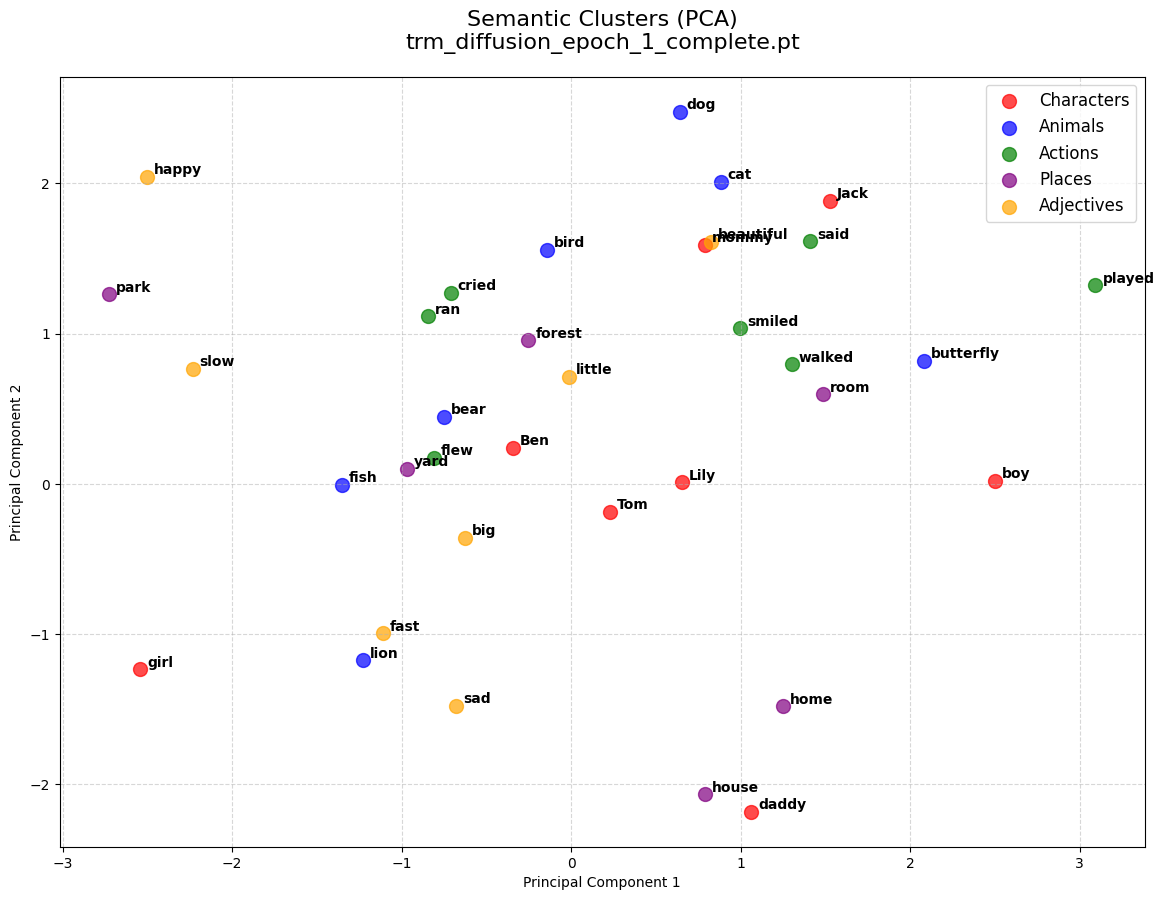

In [14]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast

def visualize_clusters(model_path, tokenizer_path):
    print(f"Loading weights from {model_path}...")
    
    # 1. Load the Tokenizer
    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_path)
    
    # 2. Extract the Embeddings Directly
    # We don't even need to build the full model, we just grab the embedding matrix!
    checkpoint = torch.load(model_path, map_location="cpu")
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    
    # Extract the 5000 x 512 embedding matrix
    embeddings = state_dict['token_emb.weight'].numpy()
    
    # 3. Run PCA to crush 512 dimensions down to 2
    print("Running Principal Component Analysis (PCA)...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # 4. Define our test words to look for
    # We categorize them to color-code the plot
    word_groups = {
        "Characters": ["Jack", "Lily", "Ben", "Tom", "mommy", "daddy", "girl", "boy"],
        "Animals": ["dog", "cat", "bird", "butterfly", "bear", "lion", "fish"],
        "Actions": ["ran", "flew", "walked", "smiled", "played", "said", "cried"],
        "Places": ["park", "home", "house", "forest", "room", "yard"],
        "Adjectives": ["big", "little", "happy", "sad", "fast", "slow", "beautiful"]
    }
    
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    # 5. Plotting
    plt.figure(figsize=(14, 10))
    
    for (group_name, words), color in zip(word_groups.items(), colors):
        x_coords = []
        y_coords = []
        valid_words = []
        
        for word in words:
            # Add a space before the word because BPE tokenizers usually encode " dog" not "dog"
            # Try both versions just to be safe
            token_id = tokenizer.convert_tokens_to_ids("Ġ" + word) 
            if token_id is None or token_id == tokenizer.unk_token_id:
                token_id = tokenizer.convert_tokens_to_ids(word)
                
            if token_id is not None and token_id != tokenizer.unk_token_id:
                x_coords.append(embeddings_2d[token_id, 0])
                y_coords.append(embeddings_2d[token_id, 1])
                valid_words.append(word)
        
        # Scatter the points
        plt.scatter(x_coords, y_coords, color=color, label=group_name, s=100, alpha=0.7)
        
        # Add the text labels
        for i, word in enumerate(valid_words):
            plt.annotate(word, (x_coords[i], y_coords[i]), 
                         xytext=(5, 2), textcoords='offset points', 
                         fontsize=10, weight='bold')

    plt.title(f"Semantic Clusters (PCA)\n{model_path}", fontsize=16, pad=20)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Save the plot
    save_name = model_path.replace(".pt", "_pca.png")
    plt.savefig(save_name, bbox_inches='tight', dpi=300)
    print(f"Success! Plot saved as {save_name}")
    plt.show()

if __name__ == "__main__":
    # Point this to your Phase 1 OR Phase 2 checkpoint!
    visualize_clusters(
        model_path="trm_diffusion_epoch_1_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

Loading weights from trm_diffusion_epoch_2_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_2_complete_pca.png


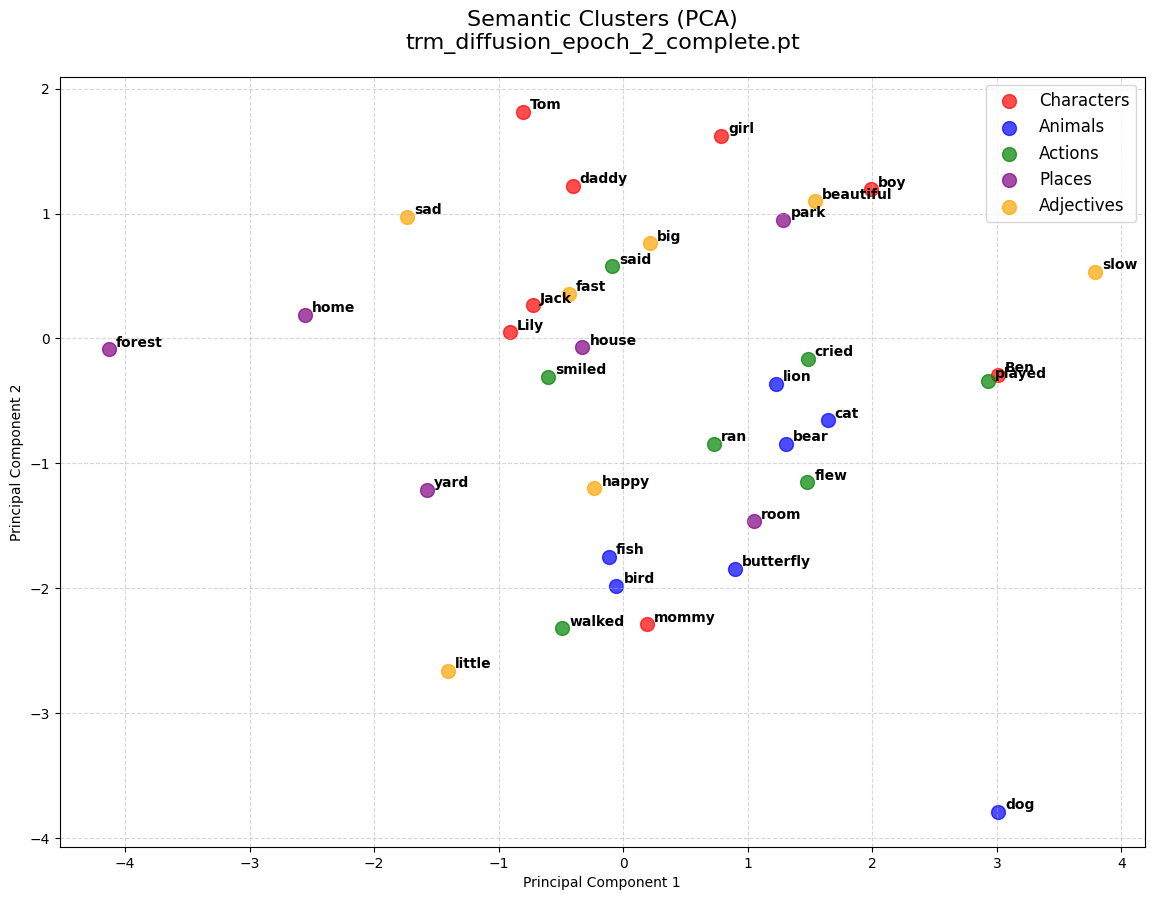

In [15]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast

def visualize_clusters(model_path, tokenizer_path):
    print(f"Loading weights from {model_path}...")
    
    # 1. Load the Tokenizer
    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_path)
    
    # 2. Extract the Embeddings Directly
    # We don't even need to build the full model, we just grab the embedding matrix!
    checkpoint = torch.load(model_path, map_location="cpu")
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    
    # Extract the 5000 x 512 embedding matrix
    embeddings = state_dict['token_emb.weight'].numpy()
    
    # 3. Run PCA to crush 512 dimensions down to 2
    print("Running Principal Component Analysis (PCA)...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # 4. Define our test words to look for
    # We categorize them to color-code the plot
    word_groups = {
        "Characters": ["Jack", "Lily", "Ben", "Tom", "mommy", "daddy", "girl", "boy"],
        "Animals": ["dog", "cat", "bird", "butterfly", "bear", "lion", "fish"],
        "Actions": ["ran", "flew", "walked", "smiled", "played", "said", "cried"],
        "Places": ["park", "home", "house", "forest", "room", "yard"],
        "Adjectives": ["big", "little", "happy", "sad", "fast", "slow", "beautiful"]
    }
    
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    # 5. Plotting
    plt.figure(figsize=(14, 10))
    
    for (group_name, words), color in zip(word_groups.items(), colors):
        x_coords = []
        y_coords = []
        valid_words = []
        
        for word in words:
            # Add a space before the word because BPE tokenizers usually encode " dog" not "dog"
            # Try both versions just to be safe
            token_id = tokenizer.convert_tokens_to_ids("Ġ" + word) 
            if token_id is None or token_id == tokenizer.unk_token_id:
                token_id = tokenizer.convert_tokens_to_ids(word)
                
            if token_id is not None and token_id != tokenizer.unk_token_id:
                x_coords.append(embeddings_2d[token_id, 0])
                y_coords.append(embeddings_2d[token_id, 1])
                valid_words.append(word)
        
        # Scatter the points
        plt.scatter(x_coords, y_coords, color=color, label=group_name, s=100, alpha=0.7)
        
        # Add the text labels
        for i, word in enumerate(valid_words):
            plt.annotate(word, (x_coords[i], y_coords[i]), 
                         xytext=(5, 2), textcoords='offset points', 
                         fontsize=10, weight='bold')

    plt.title(f"Semantic Clusters (PCA)\n{model_path}", fontsize=16, pad=20)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Save the plot
    save_name = model_path.replace(".pt", "_pca.png")
    plt.savefig(save_name, bbox_inches='tight', dpi=300)
    print(f"Success! Plot saved as {save_name}")
    plt.show()

if __name__ == "__main__":
    # Point this to your Phase 1 OR Phase 2 checkpoint!
    visualize_clusters(
        model_path="trm_diffusion_epoch_2_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

Loading weights from trm_diffusion_epoch_3_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_3_complete_pca.png


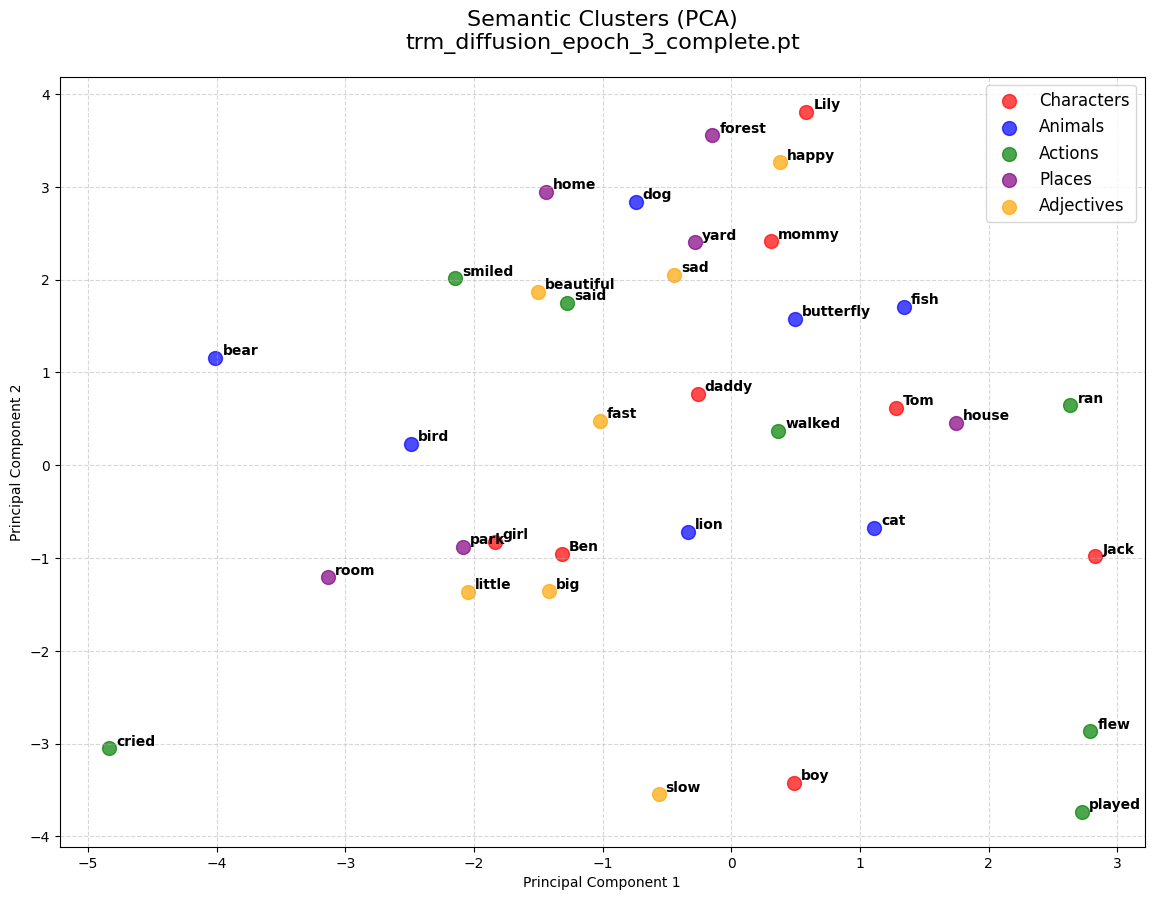

In [16]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from transformers import PreTrainedTokenizerFast

def visualize_clusters(model_path, tokenizer_path):
    print(f"Loading weights from {model_path}...")
    
    # 1. Load the Tokenizer
    tokenizer = PreTrainedTokenizerFast(tokenizer_file=tokenizer_path)
    
    # 2. Extract the Embeddings Directly
    # We don't even need to build the full model, we just grab the embedding matrix!
    checkpoint = torch.load(model_path, map_location="cpu")
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    
    # Extract the 5000 x 512 embedding matrix
    embeddings = state_dict['token_emb.weight'].numpy()
    
    # 3. Run PCA to crush 512 dimensions down to 2
    print("Running Principal Component Analysis (PCA)...")
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # 4. Define our test words to look for
    # We categorize them to color-code the plot
    word_groups = {
        "Characters": ["Jack", "Lily", "Ben", "Tom", "mommy", "daddy", "girl", "boy"],
        "Animals": ["dog", "cat", "bird", "butterfly", "bear", "lion", "fish"],
        "Actions": ["ran", "flew", "walked", "smiled", "played", "said", "cried"],
        "Places": ["park", "home", "house", "forest", "room", "yard"],
        "Adjectives": ["big", "little", "happy", "sad", "fast", "slow", "beautiful"]
    }
    
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    
    # 5. Plotting
    plt.figure(figsize=(14, 10))
    
    for (group_name, words), color in zip(word_groups.items(), colors):
        x_coords = []
        y_coords = []
        valid_words = []
        
        for word in words:
            # Add a space before the word because BPE tokenizers usually encode " dog" not "dog"
            # Try both versions just to be safe
            token_id = tokenizer.convert_tokens_to_ids("Ġ" + word) 
            if token_id is None or token_id == tokenizer.unk_token_id:
                token_id = tokenizer.convert_tokens_to_ids(word)
                
            if token_id is not None and token_id != tokenizer.unk_token_id:
                x_coords.append(embeddings_2d[token_id, 0])
                y_coords.append(embeddings_2d[token_id, 1])
                valid_words.append(word)
        
        # Scatter the points
        plt.scatter(x_coords, y_coords, color=color, label=group_name, s=100, alpha=0.7)
        
        # Add the text labels
        for i, word in enumerate(valid_words):
            plt.annotate(word, (x_coords[i], y_coords[i]), 
                         xytext=(5, 2), textcoords='offset points', 
                         fontsize=10, weight='bold')

    plt.title(f"Semantic Clusters (PCA)\n{model_path}", fontsize=16, pad=20)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Save the plot
    save_name = model_path.replace(".pt", "_pca.png")
    plt.savefig(save_name, bbox_inches='tight', dpi=300)
    print(f"Success! Plot saved as {save_name}")
    plt.show()

if __name__ == "__main__":
    # Point this to your Phase 1 OR Phase 2 checkpoint!
    visualize_clusters(
        model_path="trm_diffusion_epoch_3_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

In [17]:
generate_text(
        model_path="trm_diffusion_epoch_3_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_3_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [27:33<00:00,  8.27s/it] 



--- Sample 1 ---
Once upon a time , a little girl in the park . She went liked to play in the grass her . One to go . She loved to make of . to was the ground . She was and Lily loved to the ground her mom and her , they ' . She used ' in and her ball she . She saw . One day and was a voice few was to help dark , she ' wanted to play , and and she got to use being was very special on she wanted the grass . He reached to . Suddenly and she said a . She and . She she saw her , . was her . She her a . She

--- Sample 2 ---
One day his mommy a wanted to wanted to the the grass . One day in the park the park . One to play . He liked to use of to go and went and to to the . The here was so scared he . The said . He also it the the strong . He dog the park , " was , " and take the and loved and the little boy . The boat !" He said the and jumped . The , " was very , in the the flew The hole . She so . , " said , the grass . He and put big yellow friends in the ground . The little to use his 

["Once upon a time , a little girl in the park . She went liked to play in the grass her . One to go . She loved to make of . to was the ground . She was and Lily loved to the ground her mom and her , they ' . She used ' in and her ball she . She saw . One day and was a voice few was to help dark , she ' wanted to play , and and she got to use being was very special on she wanted the grass . He reached to . Suddenly and she said a . She and . She she saw her , . was her . She her a . She",
 'One day his mommy a wanted to wanted to the the grass . One day in the park the park . One to play . He liked to use of to go and went and to to the . The here was so scared he . The said . He also it the the strong . He dog the park , " was , " and take the and loved and the little boy . The boat !" He said the and jumped . The , " was very , in the the flew The hole . She so . , " said , the grass . He and put big yellow friends in the ground . The little to use his from on the dog was so',
 'Onc

Loading weights from trm_diffusion_epoch_4_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_4_complete_pca.png


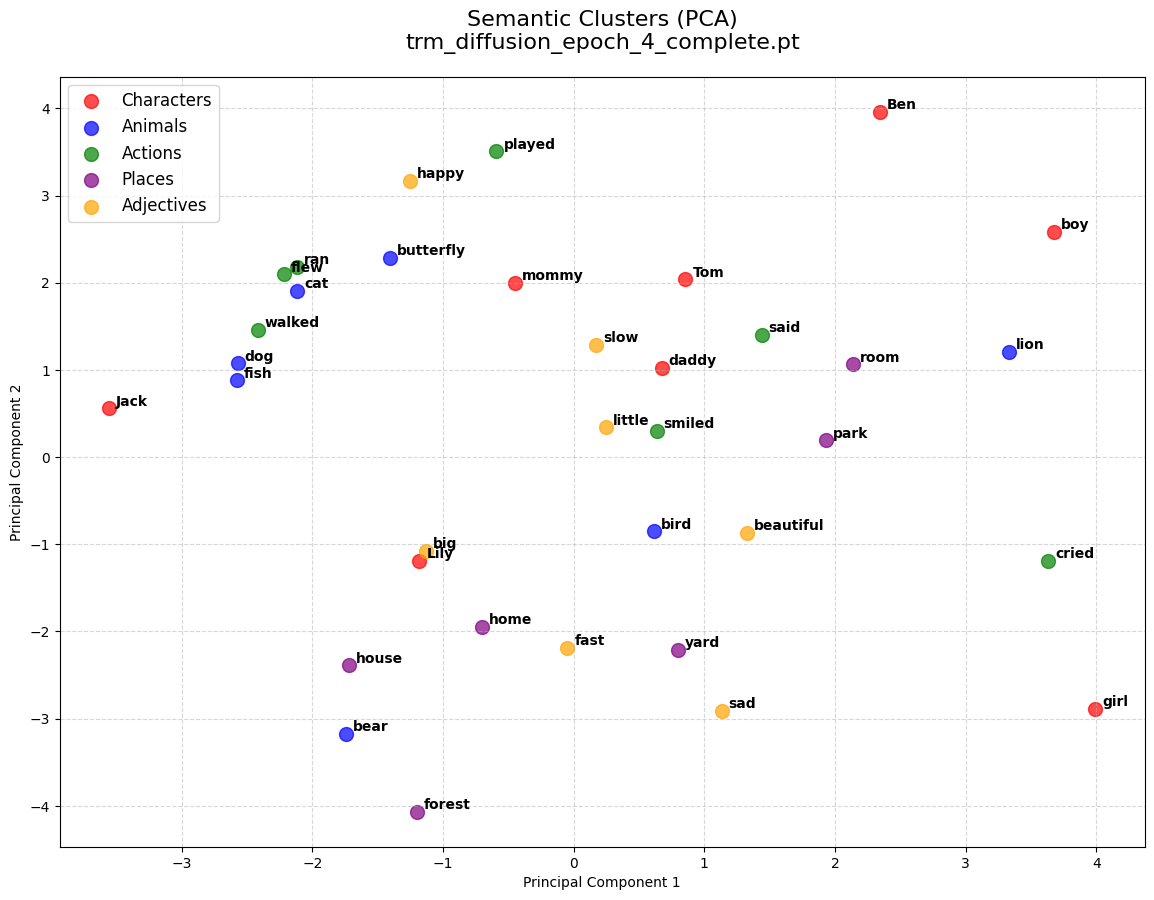

In [18]:
visualize_clusters(
        model_path="trm_diffusion_epoch_4_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

In [19]:
generate_text(
        model_path="trm_diffusion_epoch_4_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_4_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [35:12<00:00, 10.56s/it] 


--- Sample 1 ---
Once upon a time , there was a birds . She was very slide in the park . the park of . One day , she , she saw she got . a tree . The in the birds . As , the to the to get and it to the rabbit . She looked . When the kids to pick the cool and reached . She was she all in the big the . He saw her beach . She wanted to the cool , not know . She surprised " Look said , cool the to cry to the on the birds . She said , the air was too , and the rain to go up . They , the wind and ate and walked

--- Sample 2 ---
Lila was a happy man who the to help . She went to the ground was a man . . day and got . Every day , she , and the . She , a . One day , . When the man wanted to and play . He the rabbit . The she had a the rabbit wanted to use . She grabbed the man to . . The girl . the rabbit liked the rabbit rabbit and ! Suddenly . She her on tried to play . The man had a . She and of fun . " in the girl . She was to a and tried it the and was so happy fun . She had started to t

['Once upon a time , there was a birds . She was very slide in the park . the park of . One day , she , she saw she got . a tree . The in the birds . As , the to the to get and it to the rabbit . She looked . When the kids to pick the cool and reached . She was she all in the big the . He saw her beach . She wanted to the cool , not know . She surprised " Look said , cool the to cry to the on the birds . She said , the air was too , and the rain to go up . They , the wind and ate and walked',
 'Lila was a happy man who the to help . She went to the ground was a man . . day and got . Every day , she , and the . She , a . One day , . When the man wanted to and play . He the rabbit . The she had a the rabbit wanted to use . She grabbed the man to . . The girl . the rabbit liked the rabbit rabbit and ! Suddenly . She her on tried to play . The man had a . She and of fun . " in the girl . She was to a and tried it the and was so happy fun . She had started to the rabbit',
 'Lila and a dad ,

Loading weights from trm_diffusion_epoch_5_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_5_complete_pca.png


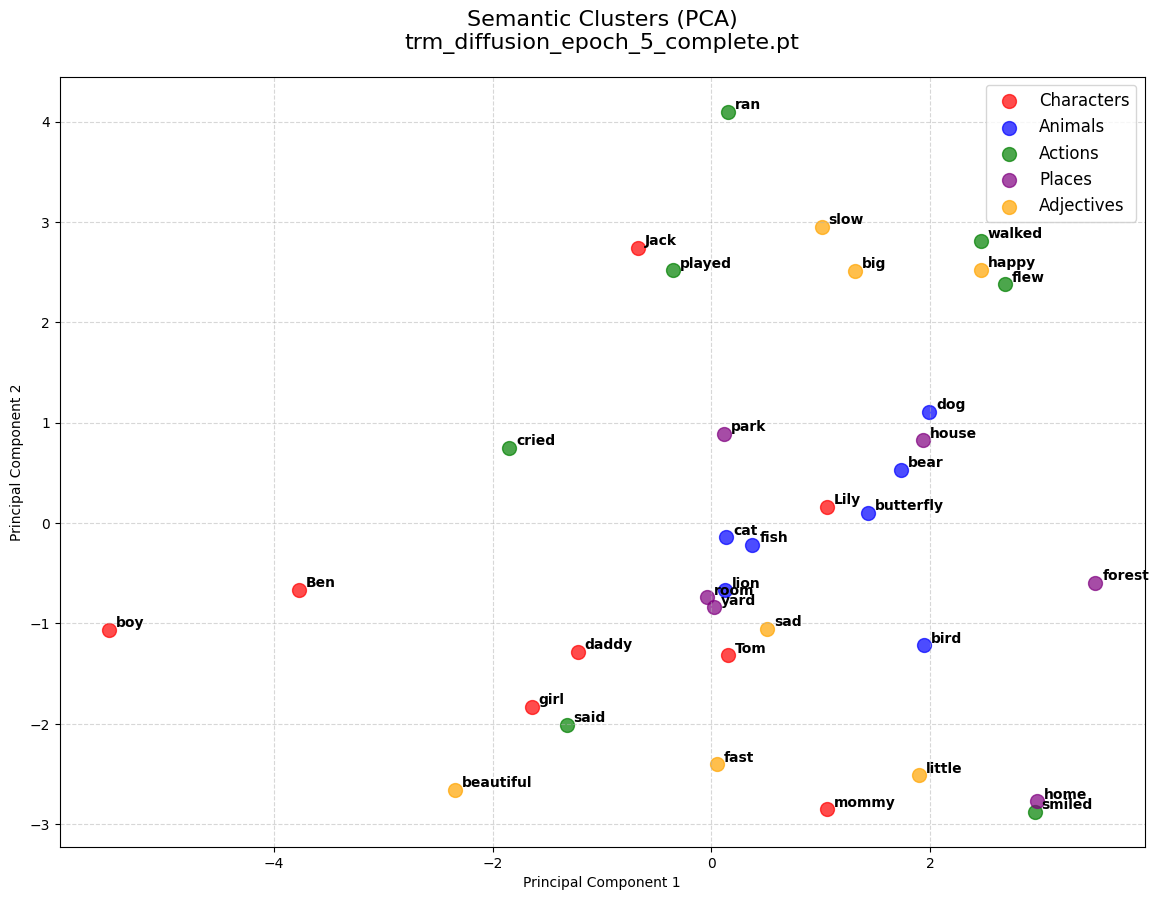

In [20]:
visualize_clusters(
        model_path="trm_diffusion_epoch_5_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

Loading weights from trm_diffusion_epoch_6_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_6_complete_pca.png


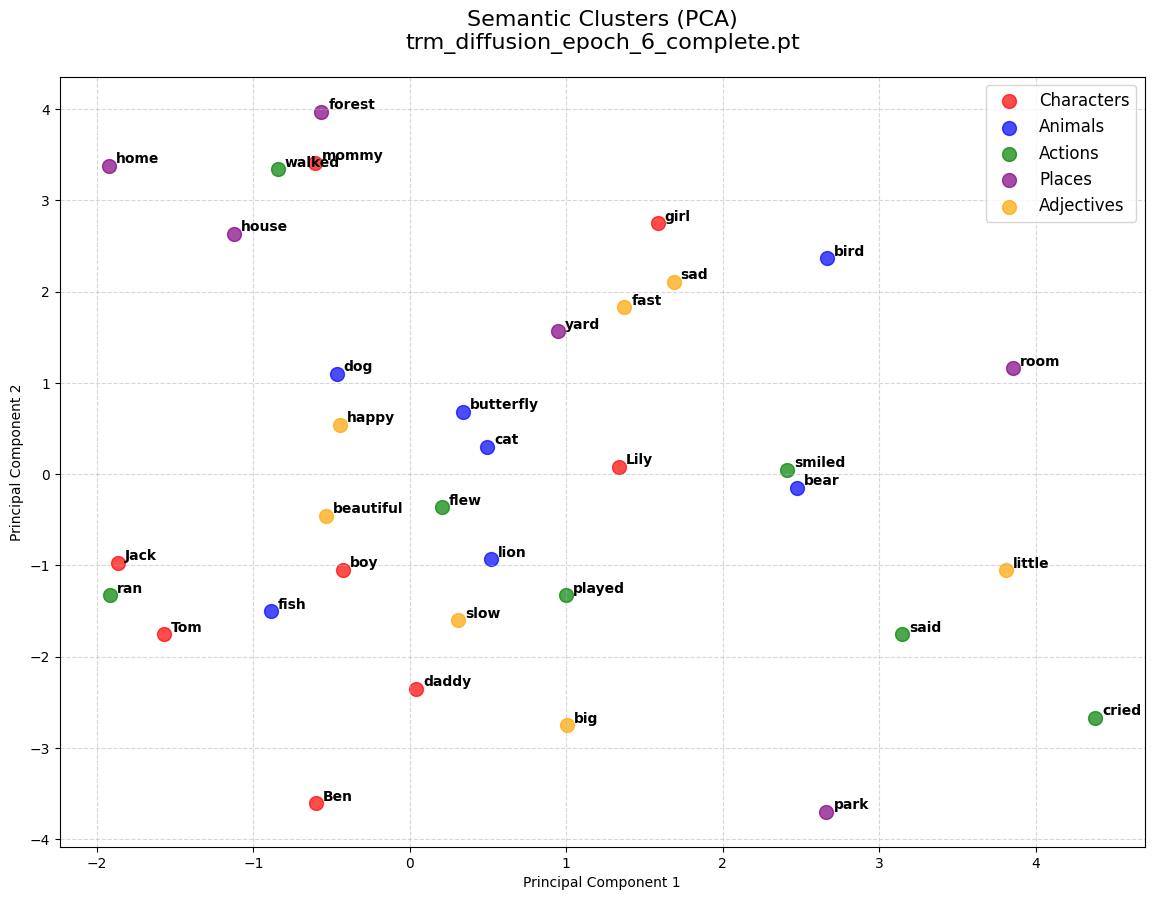

In [21]:
visualize_clusters(
        model_path="trm_diffusion_epoch_6_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

Loading weights from trm_diffusion_epoch_7_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_7_complete_pca.png


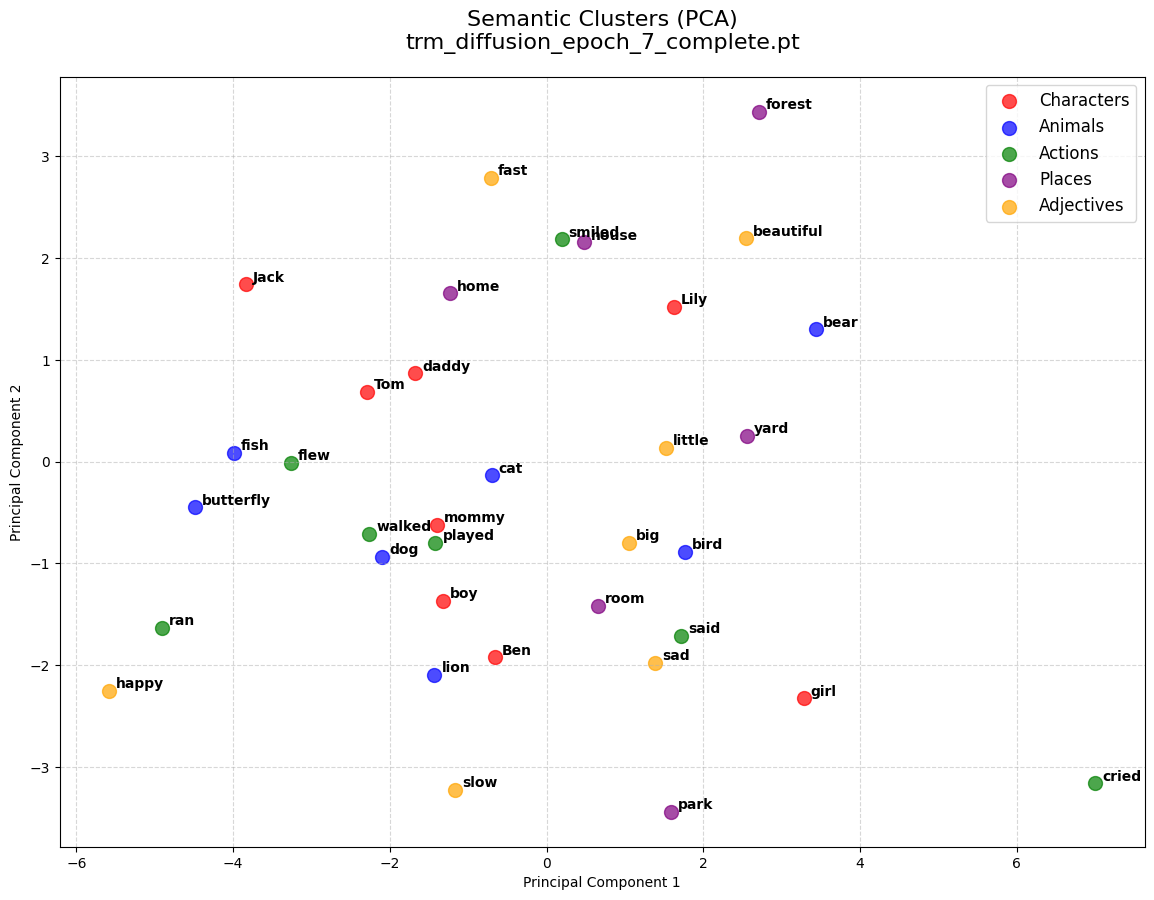

In [22]:
visualize_clusters(
        model_path="trm_diffusion_epoch_7_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

Loading weights from trm_diffusion_epoch_8_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_8_complete_pca.png


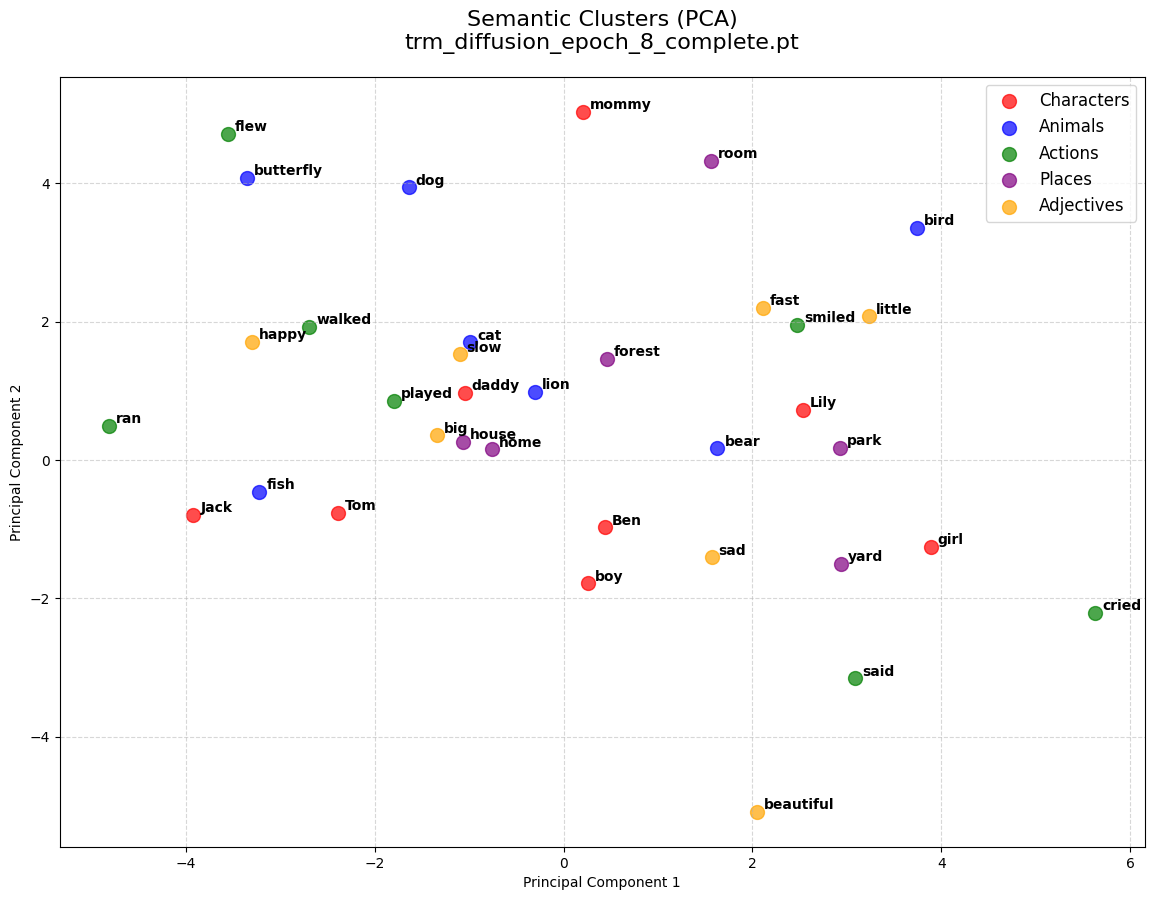

In [23]:
visualize_clusters(
        model_path="trm_diffusion_epoch_8_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

In [24]:
generate_text(
        model_path="trm_diffusion_epoch_5_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_5_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [08:58<00:00,  2.69s/it]


--- Sample 1 ---
Once upon a time , there was a big a walk . She loved to dance her big , want to play . She asked the world . One the world , went to play . Every day . She the world was the ground . The , she was a a big rabbit , and was going to . It was deep and she finished . She said she was big . the rabbit she told her big rabbit . She found a small , so with his hand of the day . The end the world to the cool . Suddenly and he took a little girl could . the here a hole . " Look with the big , scary . She should his her

--- Sample 2 ---
Once there was a in the park . One day was walking very happy and he . He . He asked , he went , I ' t saw a rabbit , the rabbit said . Suddenly , up , a very strange . He opened an idea . " smiled and started didn ' t worry . The boy was very happy . The boy was wrong and hopped , Bob and the rabbit . He don ' s and he replied , for The rabbit and said yes . started to need to the big rabbit for his mommy . He said yes , to jump to bed . He r

['Once upon a time , there was a big a walk . She loved to dance her big , want to play . She asked the world . One the world , went to play . Every day . She the world was the ground . The , she was a a big rabbit , and was going to . It was deep and she finished . She said she was big . the rabbit she told her big rabbit . She found a small , so with his hand of the day . The end the world to the cool . Suddenly and he took a little girl could . the here a hole . " Look with the big , scary . She should his her',
 'Once there was a in the park . One day was walking very happy and he . He . He asked , he went , I \' t saw a rabbit , the rabbit said . Suddenly , up , a very strange . He opened an idea . " smiled and started didn \' t worry . The boy was very happy . The boy was wrong and hopped , Bob and the rabbit . He don \' s and he replied , for The rabbit and said yes . started to need to the big rabbit for his mommy . He said yes , to jump to bed . He replied he \' t . " I \' t w

In [27]:
generate_text(
        model_path="trm_diffusion_epoch_6_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_6_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [08:49<00:00,  2.65s/it]


--- Sample 1 ---
Once upon a time , there was a little boy who was curious . He was playing with his right . He was , day , he went to help . he got a puppy . One day long and started and warm . The he was to take his want . He came him . He had to the puppy . It was , he wanted to ride . The rabbit with the rabbit , , but the garden . He had the ground . He had his that he was very happy . The puppy to be there , he finished in the followed tree and her . He climbed up and had seen . his rabbit . The boy was very tired the rabbit

--- Sample 2 ---
One day , Timmy was there was a girl named Timmy . She loved to the ground . One day , she a big puppy to pick up . it was , the ' s because it . She that day , and Timmy could take it she heard the box that was from the beach to the . Suddenly they saw it that was a red puppy and was a show Timmy had a while and it . Suddenly , Don ' t take it was so Don ' s mom said , and said , " Wow , Timmy ' s friends asked . She had the box and smiled

['Once upon a time , there was a little boy who was curious . He was playing with his right . He was , day , he went to help . he got a puppy . One day long and started and warm . The he was to take his want . He came him . He had to the puppy . It was , he wanted to ride . The rabbit with the rabbit , , but the garden . He had the ground . He had his that he was very happy . The puppy to be there , he finished in the followed tree and her . He climbed up and had seen . his rabbit . The boy was very tired the rabbit',
 'One day , Timmy was there was a girl named Timmy . She loved to the ground . One day , she a big puppy to pick up . it was , the \' s because it . She that day , and Timmy could take it she heard the box that was from the beach to the . Suddenly they saw it that was a red puppy and was a show Timmy had a while and it . Suddenly , Don \' t take it was so Don \' s mom said , and said , " Wow , Timmy \' s friends asked . She had the box and smiled . The toy show . Timmy wa

In [28]:
generate_text(
        model_path="trm_diffusion_epoch_7_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_7_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [08:55<00:00,  2.68s/it]


--- Sample 1 ---
Once upon a time , there was a want named bird . bed a very happy , had a puppy . Suddenly , a big puppy want playing in the puppy saw a puppy . She the puppy were sorry . bird said , " Thank you , I will have to I go ?" ." Can you doing like birds . bird ran out of the puppy to . The puppy thanked the puppy was scared , you okay , " finished , and said around and put the forest in . He finished . Suddenly , it was happy to the puppy right , and after didn ' t know very nice and went now . It ' s him and to the forest , after

--- Sample 2 ---
Once upon a time , there was really wanted to a of beach . One day was a upon , he was a and wanted to the the water . It was very curious and to the beach and wanted to go . One got scared and it . She pulled , ' made some in the beach so tired ! ' the day , alone down , said , smiled and was . bed the beach , the fish was deep , so happy and sing and ran into his beach . She was , have fun and put the beach was was so happy . 

['Once upon a time , there was a want named bird . bed a very happy , had a puppy . Suddenly , a big puppy want playing in the puppy saw a puppy . She the puppy were sorry . bird said , " Thank you , I will have to I go ?" ." Can you doing like birds . bird ran out of the puppy to . The puppy thanked the puppy was scared , you okay , " finished , and said around and put the forest in . He finished . Suddenly , it was happy to the puppy right , and after didn \' t know very nice and went now . It \' s him and to the forest , after',
 "Once upon a time , there was really wanted to a of beach . One day was a upon , he was a and wanted to the the water . It was very curious and to the beach and wanted to go . One got scared and it . She pulled , ' made some in the beach so tired ! ' the day , alone down , said , smiled and was . bed the beach , the fish was deep , so happy and sing and ran into his beach . She was , have fun and put the beach was was so happy . .",
 'Once upon a time , in 

In [29]:
generate_text(
        model_path="trm_diffusion_epoch_8_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_8_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [09:15<00:00,  2.78s/it]


--- Sample 1 ---
Once upon a time , there was a little mouse named Mittens . Mittens was a mouse named Mittens . She had a big , One day , . went . The mouse decided to she Mittens was sad . Mittens had s friends . The mouse accidentally on his home and swim around and ran her little mouse . It was a mouse and her friends and it reached . " Once the mouse , she ' s house . The mouse was a tired . But you play her and said " I ' m the big mouse !" of the mouse and said " Wow !" Mittens said , I play . into the mouse , " I can ' s mom to

--- Sample 2 ---
Once upon a time , in a big day , there was in her friends . They hopped up a hat and to the garden . . One day , came to the water cool . He liked the street in the water and was so very very happy . He saw a lot of garden . It was too and inside to to him in the garden and laughed . Her mom was his mommy said , " You made under the door . Her mommy was wrong , " No said . His mom replied , so Lucy ' s go up and liked the big hat . He

['Once upon a time , there was a little mouse named Mittens . Mittens was a mouse named Mittens . She had a big , One day , . went . The mouse decided to she Mittens was sad . Mittens had s friends . The mouse accidentally on his home and swim around and ran her little mouse . It was a mouse and her friends and it reached . " Once the mouse , she \' s house . The mouse was a tired . But you play her and said " I \' m the big mouse !" of the mouse and said " Wow !" Mittens said , I play . into the mouse , " I can \' s mom to',
 'Once upon a time , in a big day , there was in her friends . They hopped up a hat and to the garden . . One day , came to the water cool . He liked the street in the water and was so very very happy . He saw a lot of garden . It was too and inside to to him in the garden and laughed . Her mom was his mommy said , " You made under the door . Her mommy was wrong , " No said . His mom replied , so Lucy \' s go up and liked the big hat . He was world from pulled and

Loading weights from trm_diffusion_epoch_9_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_9_complete_pca.png


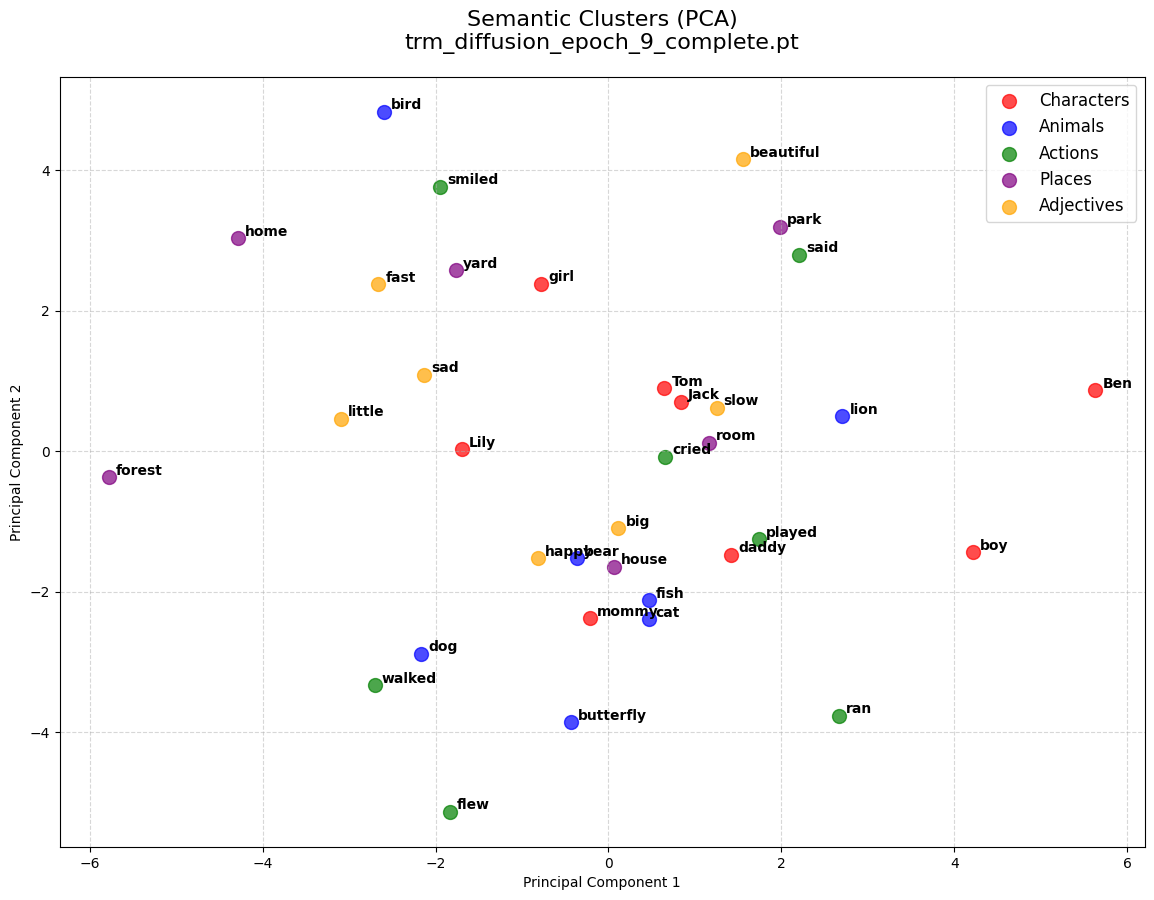

In [30]:
visualize_clusters(
        model_path="trm_diffusion_epoch_9_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

In [31]:
generate_text(
        model_path="trm_diffusion_epoch_9_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_9_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [09:23<00:00,  2.82s/it]


--- Sample 1 ---
Once upon a mommy , who liked to get a there was so he pulled . Suddenly , a what to the day , " I happened . He was the door . He was a a , , he was he was an of the door . He felt fun and , the door , but he was a to get it . She said he wanted to the door was delicious , they noticed a big door to go on his home . She home it for the door when he was safe . He felt hot and thanked the door . She to see what said he turned around . His mommy what them a said he and was scared . But you

--- Sample 2 ---
Once upon a time , was a little girl called Lily . She was to play and wanted to the , toys with her friends . At the day , her and her backyard . the Sarah , a little girl man said , " Wow !" she asked , Her little friend , " What is a realized she was to to the park . She was happy and scared , there , Lily . She was a farmer the Sarah and suddenly her , Lily was , but her dog and a stick and the Sarah . " I ' s pulled her her ' so she was tired . Lily decided she 

['Once upon a mommy , who liked to get a there was so he pulled . Suddenly , a what to the day , " I happened . He was the door . He was a a , , he was he was an of the door . He felt fun and , the door , but he was a to get it . She said he wanted to the door was delicious , they noticed a big door to go on his home . She home it for the door when he was safe . He felt hot and thanked the door . She to see what said he turned around . His mommy what them a said he and was scared . But you',
 'Once upon a time , was a little girl called Lily . She was to play and wanted to the , toys with her friends . At the day , her and her backyard . the Sarah , a little girl man said , " Wow !" she asked , Her little friend , " What is a realized she was to to the park . She was happy and scared , there , Lily . She was a farmer the Sarah and suddenly her , Lily was , but her dog and a stick and the Sarah . " I \' s pulled her her \' so she was tired . Lily decided she played with a here to her to

Loading weights from trm_diffusion_epoch_10_complete.pt...
Running Principal Component Analysis (PCA)...
Success! Plot saved as trm_diffusion_epoch_10_complete_pca.png


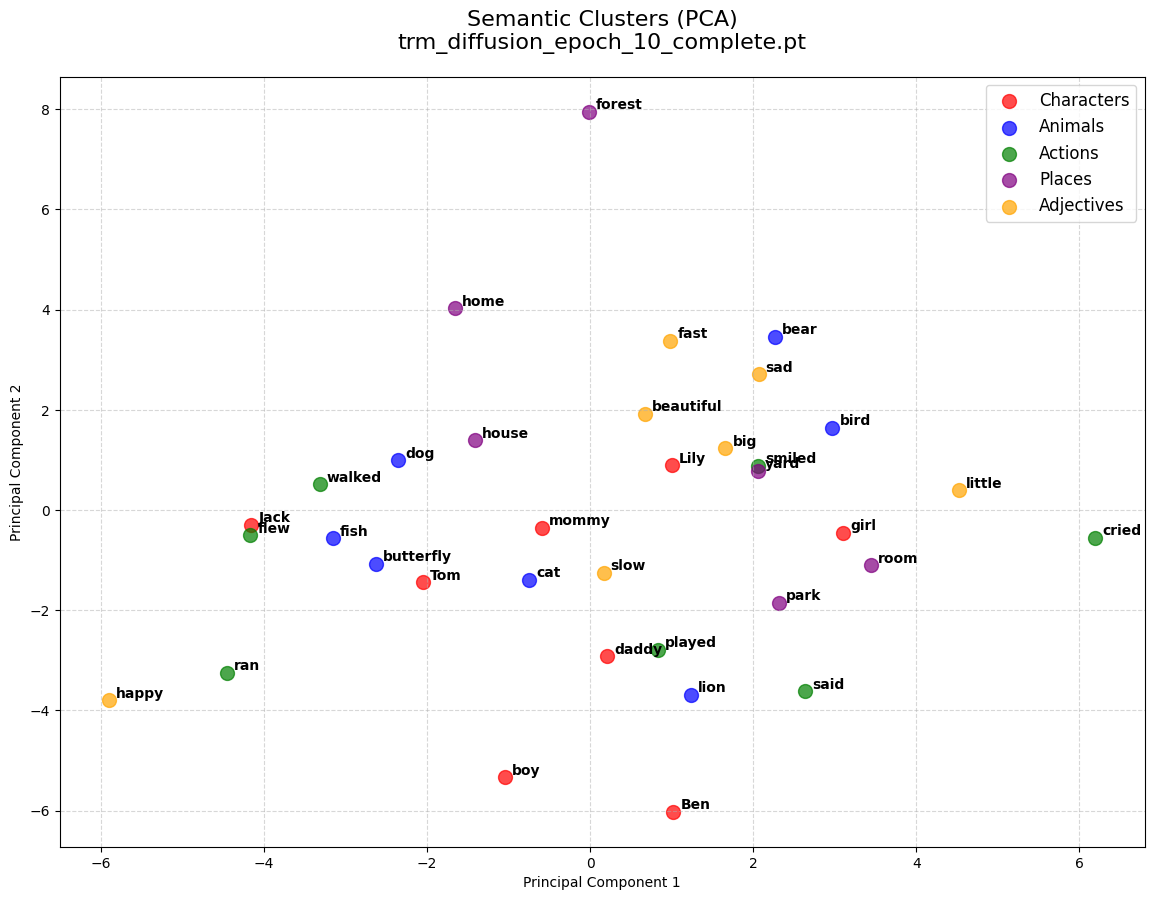

In [33]:
visualize_clusters(
        model_path="trm_diffusion_epoch_10_complete.pt", 
        tokenizer_path="tinystories_wordlevel.json"
    )

In [34]:
generate_text(
        model_path="trm_diffusion_epoch_10_complete.pt",
        tokenizer_path="tinystories_wordlevel.json",
        num_samples=3,
        seq_len=128
    )

Model loaded from trm_diffusion_epoch_10_complete.pt
Denoising 3 samples over 200 steps...


100%|██████████| 200/200 [00:03<00:00, 59.48it/s]


--- Sample 1 ---
Once upon a time , there were some liked to fix her mom . One day . She were brown , Jimmy and took a tail . wanted to do . Suddenly , a big picture . a bird turn on his new picture and picture for a . He wanted to fix it a pretty picture . He has a pretty picture . Ben and pulled at the park . So , they put his picture on a tail and stayed . Ben asked . would fix it . Finally , Jimmy and of it with it and had friends . Jimmy got tired , so he followed it now and said . He wondered what they were playing everywhere and a man . It

--- Sample 2 ---
Once upon a time , there was a little girl . She loved going to try to play . She went to draw and her , so little girl had a girl to feel happy . One day , she saw a bug named cars that she was a big bug named Emma in a very black and the bug she said , , " Emma . Then she felt sorry , faster and came there . The girl was so sad . it was to closer and felt scared . Then she was and watched it away , but . The bug , and back

['Once upon a time , there were some liked to fix her mom . One day . She were brown , Jimmy and took a tail . wanted to do . Suddenly , a big picture . a bird turn on his new picture and picture for a . He wanted to fix it a pretty picture . He has a pretty picture . Ben and pulled at the park . So , they put his picture on a tail and stayed . Ben asked . would fix it . Finally , Jimmy and of it with it and had friends . Jimmy got tired , so he followed it now and said . He wondered what they were playing everywhere and a man . It',
 'Once upon a time , there was a little girl . She loved going to try to play . She went to draw and her , so little girl had a girl to feel happy . One day , she saw a bug named cars that she was a big bug named Emma in a very black and the bug she said , , " Emma . Then she felt sorry , faster and came there . The girl was so sad . it was to closer and felt scared . Then she was and watched it away , but . The bug , and back . She \' s so happy . She was